<a href="https://www.kaggle.com/code/taimour/image-processing-3-salt-pepper?scriptVersionId=284311453" target="_blank"><img align="left" alt="Kaggle" title="Open in Kaggle" src="https://kaggle.com/static/images/open-in-kaggle.svg"></a>

# <span style="display:block; color:#0066cc; font-family: 'Consolas', monospace; text-align: center; border-top:6px solid #ff6b6b; padding:15px; background-color:#f0f8ff; border-radius:8px; font-weight: bold; letter-spacing:1px">🖼️ 3-Salt & Pepper</span>

# <span style="display:block; color:#0066cc; font-family: 'Consolas', monospace; border-top:6px solid #ff6b6b; padding:15px; background-color:#f0f8ff; border-radius:8px; font-weight: bold; letter-spacing:1px">Imports</span>

In [1]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

# <span style="display:block; color:#0066cc; font-family: 'Consolas', monospace; border-top:6px solid #ff6b6b; padding:15px; background-color:#f0f8ff; border-radius:8px; font-weight: bold; letter-spacing:1px">Show Image</span>

In [2]:
def show_image(img, title):
    plt.figure(figsize=(6,6))
    plt.imshow(img, cmap='gray')
    plt.title(title)
    plt.axis('off')
    plt.show()

# <span style="display:block; color:#0066cc; font-family: 'Consolas', monospace; border-top:6px solid #ff6b6b; padding:15px; background-color:#f0f8ff; border-radius:8px; font-weight: bold; letter-spacing:1px">Add Salt & Pepper</span>

In [3]:
def add_salt_pepper(img, salt_prob=0.01, pepper_prob=0.01):
    #create copy of orginal image
    noisy_img = img.copy()
    total_pixels = img.size

    #add salt (white pixels)
    num_salt = int(salt_prob * total_pixels)
    pixel_coords = [np.random.randint(0, i-1, num_salt) for i in img.shape]
    #noisy_img[row_numpy_array, column_numpy_array]
    noisy_img[pixel_coords[0], pixel_coords[1]] = 255

    #add pepper (black pixels)
    num_pepper = int(pepper_prob * total_pixels)
    pixel_coords = [np.random.randint(0, i-1, num_pepper) for i in img.shape]
    noisy_img[pixel_coords[0], pixel_coords[1]] = 0

    return noisy_img

# <span style="display:block; color:#0066cc; font-family: 'Consolas', monospace; border-top:6px solid #ff6b6b; padding:15px; background-color:#f0f8ff; border-radius:8px; font-weight: bold; letter-spacing:1px">Median Filter</span>

In [4]:
def apply_median_filter(noisy_img, kernel_size=3):
    if kernel_size % 2==0:
        raise ValueError("Kernel size can only be an odd number")
    return cv2.medianBlur(noisy_img, kernel_size)

# <span style="display:block; color:#0066cc; font-family: 'Consolas', monospace; border-top:6px solid #ff6b6b; padding:15px; background-color:#f0f8ff; border-radius:8px; font-weight: bold; letter-spacing:1px">Execution</span>

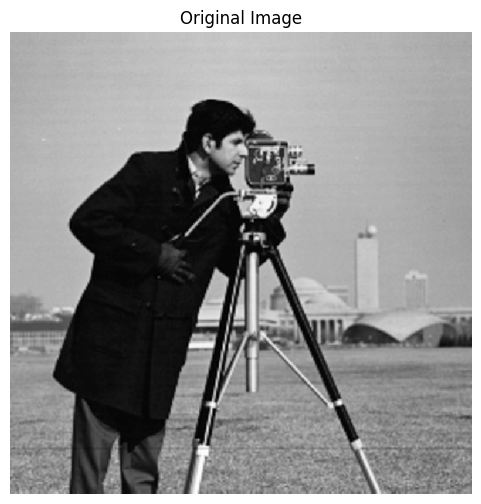

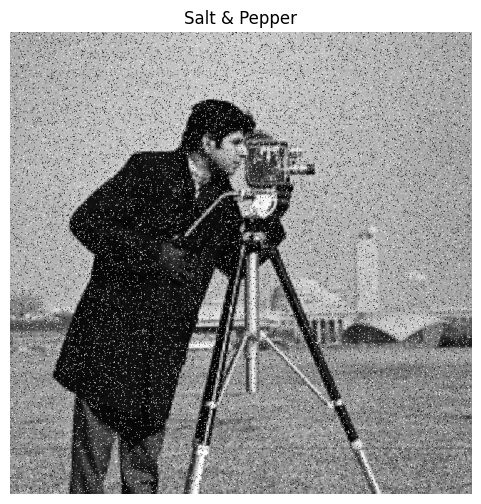

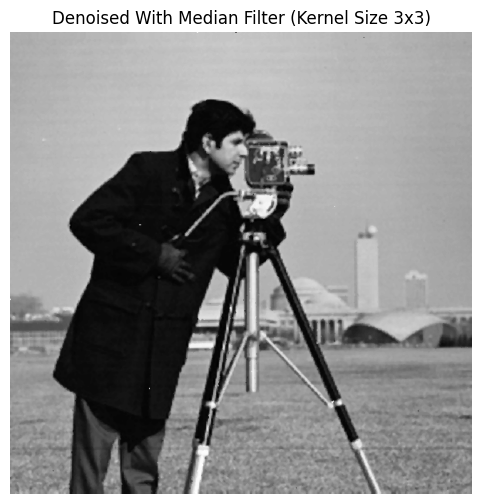

In [5]:
if __name__=="__main__":
    img_path = "/kaggle/input/image-processing/Grayscale/cameraman.png"
    img = cv2.imread(img_path, cv2.IMREAD_GRAYSCALE)
    show_image(img, "Original Image")

    # add salt and pepper noise
    img_salt_pepper=add_salt_pepper(img, salt_prob=0.05, pepper_prob=0.05)
    show_image(img_salt_pepper, "Salt & Pepper")

    # denoise salt and pepper
    median_filter_3x3 = apply_median_filter(img_salt_pepper,3)
    show_image(median_filter_3x3, "Denoised With Median Filter (Kernel Size 3x3)")